In [1]:
import pandas as pd
data = r'C:\Users\MSI\ML-final-project\Academic-Predictor-machine-based-on-performance-\data\preprocessed\preprocessed_data(1).csv'
df = pd.read_csv(data)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   598 non-null    int64  
 1   Year                     598 non-null    float64
 2   STEM_Major               598 non-null    int64  
 3   Diet_Quality             598 non-null    int64  
 4   Internet_Quality         598 non-null    int64  
 5   Employment               598 non-null    int64  
 6   Stress_Level             598 non-null    float64
 7   AI_Tool_Usage            598 non-null    int64  
 8   GPA                      598 non-null    float64
 9   Performance_Tier         598 non-null    int64  
 10  Total_Productive_Hrs     598 non-null    float64
 11  Distraction_Hrs          598 non-null    float64
 12  Study_Distraction_Ratio  598 non-null    float64
 13  Wellbeing_Score          598 non-null    float64
 14  Available_Study_Time     5

In [3]:
df.head(20)

,Gender,Year,STEM_Major,Diet_Quality,Internet_Quality,Employment,Stress_Level,AI_Tool_Usage,GPA,Performance_Tier,...,Resource_Quality,Focus_Ratio,Stress_Wellbeing,AI_Engagement,Lifestyle_Index,Study_Consistency,Time_Efficiency,Digital_Balance,Academic_Momentum,Stress_Load
0,1,2.0,1,3,3,0,5.5,3,3.39,2,...,9,1.904762,0.500000,34.5,0.658730,1,0.615385,1.428571,11.5,13.0625
1,0,1.0,1,4,3,0,5.5,4,3.69,2,...,12,1.250000,0.458333,42.0,0.773810,3,0.923077,2.500000,31.5,10.3125
2,1,1.0,1,2,3,0,7.5,3,3.48,2,...,6,0.980392,1.071429,37.5,0.448413,4,0.705882,0.588235,25.0,38.4375
3,1,2.0,1,3,3,0,5.5,4,3.50,2,...,9,0.487805,1.000000,44.8,0.500000,6,0.923077,0.975610,33.6,24.0625
4,1,2.0,1,2,2,0,7.5,4,3.70,2,...,4,0.784314,1.250000,44.8,0.333333,6,1.411765,0.784314,33.6,46.8750
5,1,3.0,1,2,4,0,9.5,4,2.90,1,...,8,0.465116,1.461538,38.8,0.515873,6,1.142857,0.465116,29.1,81.9375
6,0,2.0,0,2,3,0,3.5,3,3.05,2,...,6,0.196078,0.411765,33.6,0.496032,9,0.666667,0.588235,33.6,21.8750
7,1,1.0,1,3,1,0,7.5,3,3.00,2,...,3,1.951220,0.789474,40.5,0.444444,3,0.352941,0.731707,13.5,30.9375
8,1,3.0,0,2,2,2,1.5,2,3.50,2,...,4,1.428571,0.107143,22.4,0.587302,6,3.600000,0.952381,33.6,3.5625
9,1,3.0,1,3,1,1,5.5,1,3.89,2,...,3,0.487805,1.222222,10.5,0.333333,2,0.000000,0.243902,21.0,22.6875


In [4]:
df.shape


(598, 28)

In [5]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X = df.drop(['GPA', 'Performance_Tier', 'Available_Study_Time'], axis=1)
Y = df['Performance_Tier']
from functools import partial
# ❌ Remove: X_selected = SelectKBest(...).fit(X, Y)  ← leaks test data
# Just define it here, fit inside Cell 5 after split
X_selector = SelectKBest(score_func=partial(mutual_info_classif, random_state=42), k=20)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y  # ← added stratify
)

# Fit selector ONLY on train
X_selected_train = X_selector.fit_transform(X_train, y_train)
X_selected_test = X_selector.transform(X_test)

print(X_train.columns[X_selector.get_support(indices=True)])

Index(['Diet_Quality', 'Stress_Level', 'AI_Tool_Usage', 'Total_Productive_Hrs',
       'Distraction_Hrs', 'Study_Distraction_Ratio', 'Wellbeing_Score',
       'Active_Engagement_Score', 'Study_Quality', 'AI_Enhanced_Study',
       'Resource_Quality', 'Focus_Ratio', 'Stress_Wellbeing', 'AI_Engagement',
       'Lifestyle_Index', 'Study_Consistency', 'Time_Efficiency',
       'Digital_Balance', 'Academic_Momentum', 'Stress_Load'],
      dtype='object')


In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_selected_train_bal, y_train_bal = smote.fit_resample(X_selected_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_bal).value_counts())

After SMOTE:
Performance_Tier
0    256
1    256
2    256
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
X_train_scaled = s.fit_transform(X_selected_train_bal)
X_test_scaled = s.transform(X_selected_test)
X_train_scaled

array([[-1.66963883, -1.54099438, -2.94235125, ..., -1.11301934,
        -0.02986671, -0.36557002],
       [ 0.83424719,  0.65043604, -0.9099947 , ..., -0.62412164,
         0.94066773,  0.40291403],
       [-0.41769582, -0.44527917,  1.12236185, ...,  0.49561178,
        -0.87670559, -0.71605019],
       ...,
       [-0.35894445,  0.70185593,  1.07467449, ..., -0.13235607,
         0.68602654,  0.40306492],
       [-0.41769582,  1.74615125,  0.78626058, ..., -0.21607548,
        -1.02353688,  0.95596531],
       [ 0.14221695, -2.14666736, -0.9099947 , ..., -0.13740945,
        -0.41959984, -1.29847658]], shape=(768, 20))

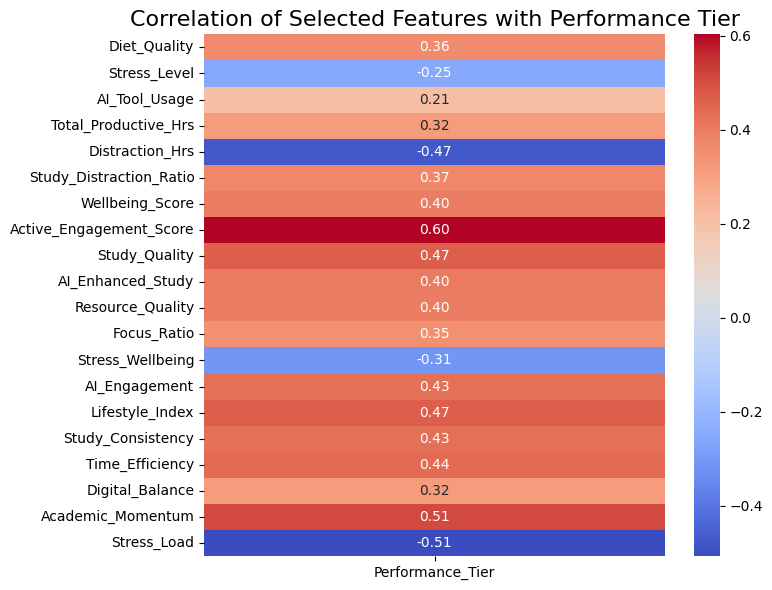

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# ✅ use X_selector (the SelectKBest object), not X_selected_train (the array)
selected_mask = X_selector.get_support()
selected_features = X_train.columns[selected_mask]

# Rebuild as DataFrame and add target
df_selected = pd.DataFrame(X_selected_train, columns=selected_features)
df_selected['Performance_Tier'] = y_train.values

# Plot correlation with Performance_Tier only
plt.figure(figsize=(8, 6))
corr = df_selected.corr()[['Performance_Tier']].drop('Performance_Tier')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Selected Features with Performance Tier', fontsize=16)
plt.tight_layout()
plt.show()


In [22]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

# ── Fixed models with regularization to prevent overfitting ──
models = {
    'lr' : LogisticRegression(
                C=0.1, max_iter=1000, solver='lbfgs',
                class_weight='balanced', random_state=42),
    'rf' : RandomForestClassifier(
                n_estimators=100, max_depth=4,          # shallow depth
                min_samples_split=20, min_samples_leaf=10,
                max_features='sqrt', random_state=42),
    'gb' : GradientBoostingClassifier(
                n_estimators=50,                         # ← was 100, fewer trees
                max_depth=1,                             # ← was 2, stumps only
                learning_rate=0.05,
                subsample=0.6,                           # ← was 0.7
                min_samples_leaf=20,                     # ← was 10
                random_state=42),
    'xgb': XGBClassifier(
                n_estimators=50,                         # ← was 100
                max_depth=1,                             # ← was 2, stumps only
                learning_rate=0.05,
                subsample=0.6,                           # ← was 0.7
                colsample_bytree=0.7,                    # ← new, random feature subset
                reg_alpha=5.0,                           # ← was 1.0
                reg_lambda=10.0,                         # ← was 5.0
                eval_metric='mlogloss', random_state=42),
}

# ── Train & evaluate ──
print(f"{'Model':<6} | {'Train':>7} | {'Test':>7} | {'Gap':>7} | Status")
print("-" * 50)
for name, model in models.items():
    model.fit(X_train_scaled, y_train_bal)
    train_acc = accuracy_score(y_train_bal, model.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test,      model.predict(X_test_scaled))
    gap       = train_acc - test_acc
    flag      = "OVERFIT" if gap > 0.1 else " OK"
    print(f"{name:<6} | {train_acc:>7.2%} | {test_acc:>7.2%} | {gap:>7.2%} | {flag}")
 

Model  |   Train |    Test |     Gap | Status
--------------------------------------------------
lr     |  73.70% |  78.33% |  -4.64% |  OK
rf     |  81.90% |  72.50% |   9.40% |  OK
gb     |  77.34% |  72.50% |   4.84% |  OK
xgb    |  72.01% |  72.50% |  -0.49% |  OK


In [23]:

print(f"\n{'Model':<6} | {'Correct':>8} | {'Wrong':>8} | {'Total':>8} | "
      f"{'Accuracy':>9} | {'Precision':>9} | {'Recall':>9} | {'F1_Score':>9}")
print("-" * 100)

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    correct = (y_pred == y_test).sum()
    wrong   = (y_pred != y_test).sum()
    total   = len(y_test)

    test_acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"{name:<6} | {correct:>8} | {wrong:>8} | {total:>8} | "
          f"{test_acc:>9.2%} | {precision:>9.2%} | {recall:>9.2%} | {f1:>9.2%}")


Model  |  Correct |    Wrong |    Total |  Accuracy | Precision |    Recall |  F1_Score
----------------------------------------------------------------------------------------------------
lr     |       94 |       26 |      120 |    78.33% |    79.55% |    78.33% |    78.73%
rf     |       87 |       33 |      120 |    72.50% |    74.92% |    72.50% |    73.29%
gb     |       87 |       33 |      120 |    72.50% |    73.57% |    72.50% |    72.75%
xgb    |       87 |       33 |      120 |    72.50% |    73.21% |    72.50% |    72.66%


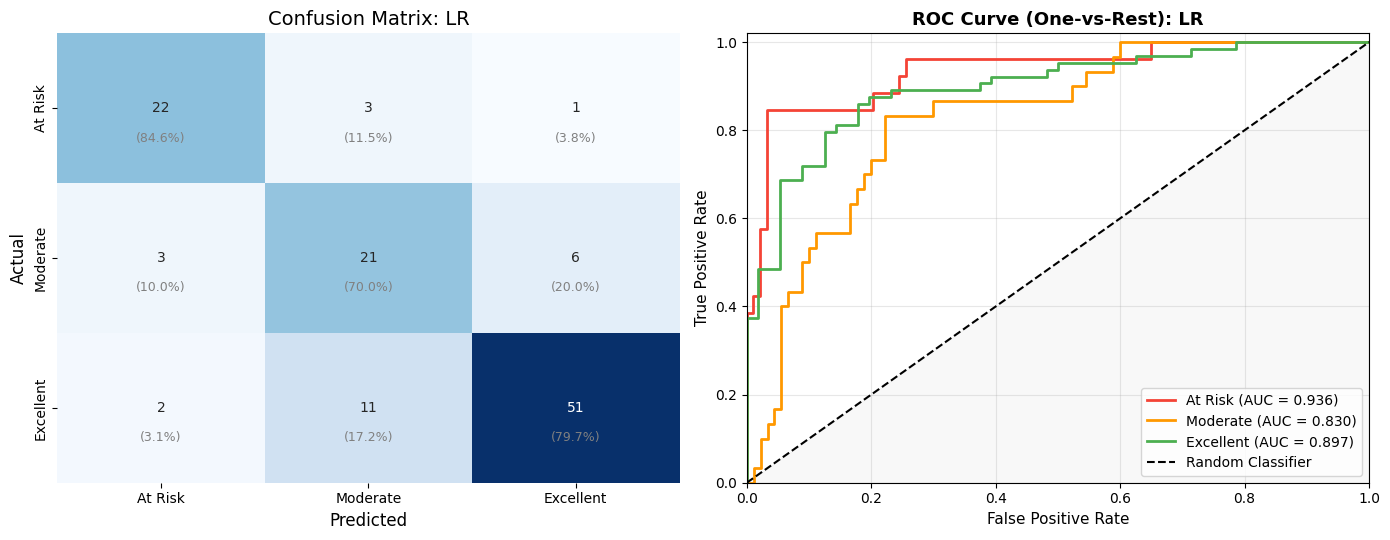

=== AUC Summary: LR ===
  At Risk    AUC : 0.9358
  Moderate   AUC : 0.8300
  Excellent  AUC : 0.8968



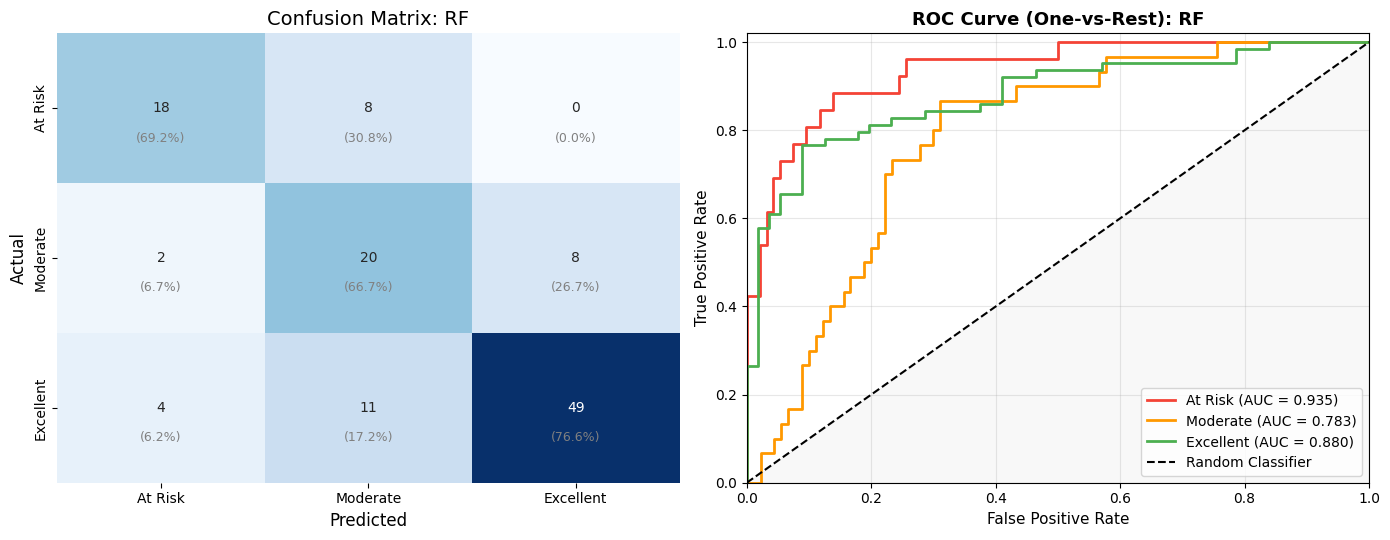

=== AUC Summary: RF ===
  At Risk    AUC : 0.9349
  Moderate   AUC : 0.7826
  Excellent  AUC : 0.8797



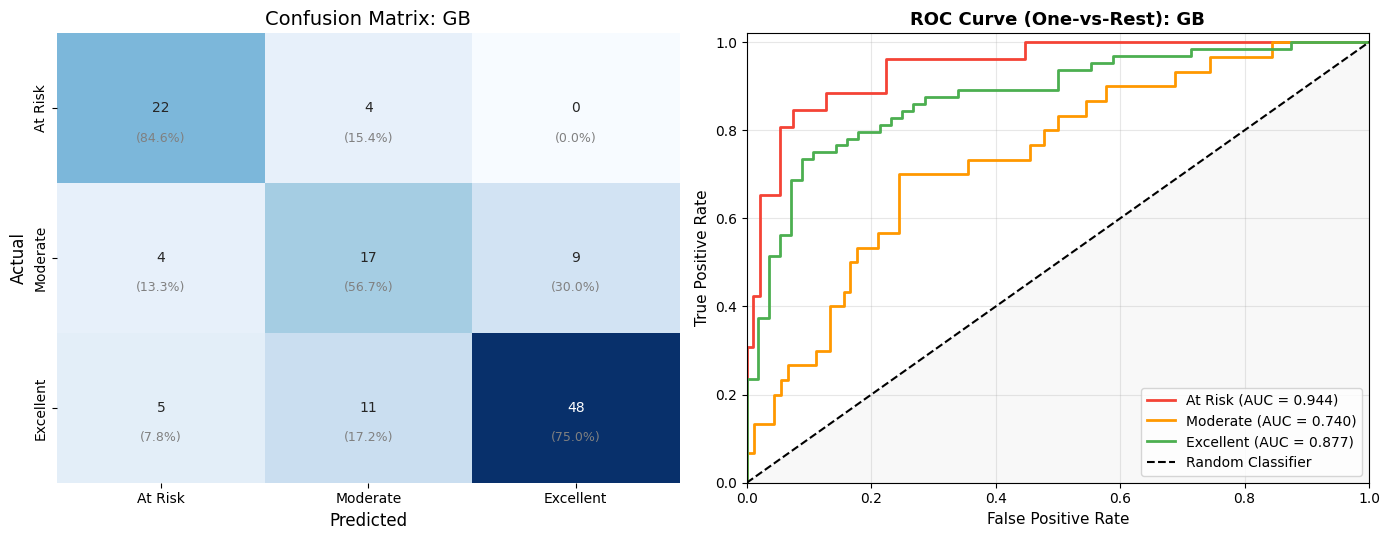

=== AUC Summary: GB ===
  At Risk    AUC : 0.9435
  Moderate   AUC : 0.7404
  Excellent  AUC : 0.8767



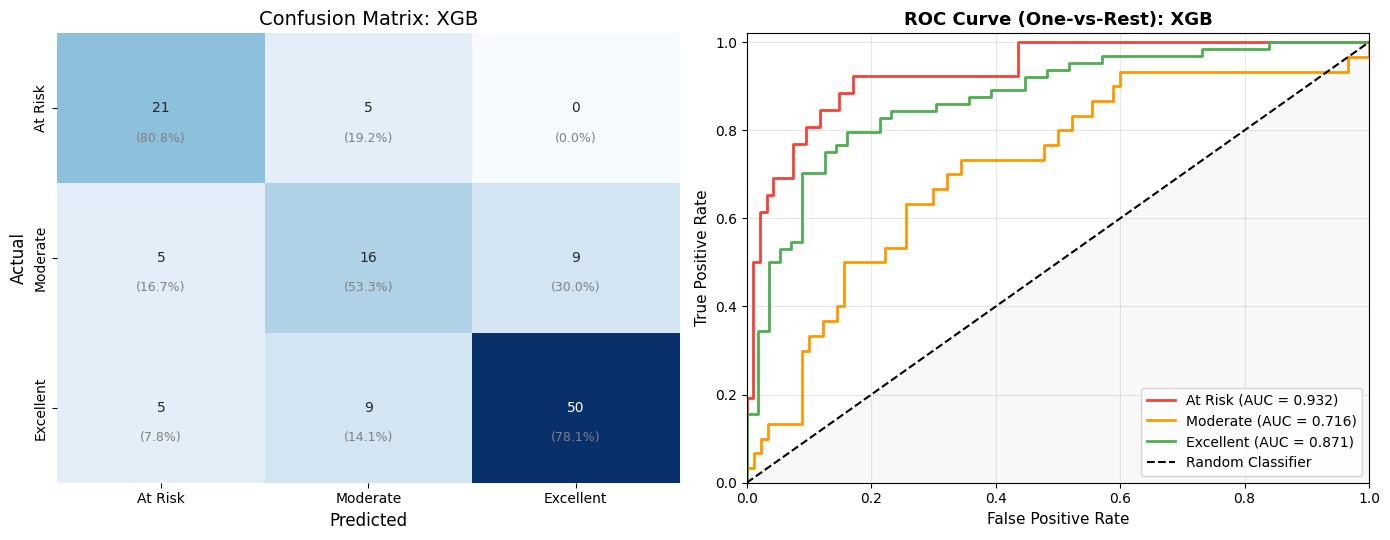

=== AUC Summary: XGB ===
  At Risk    AUC : 0.9317
  Moderate   AUC : 0.7163
  Excellent  AUC : 0.8714



In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

class_names = ['At Risk', 'Moderate', 'Excellent']
colors      = ['#F44336', '#FF9800', '#4CAF50']

for name, model in models.items():

    # ── Predictions ──
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    y_test_bin = label_binarize(y_test, classes=model.classes_)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # ── Plot 1: Confusion Matrix ──
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            pct = cm[i, j] / cm[i].sum() * 100
            axes[0].text(j + 0.5, i + 0.7, f'({pct:.1f}%)',
                         ha='center', va='center', fontsize=9, color='gray')

    axes[0].set_title(f'Confusion Matrix: {name.upper()}', fontsize=14)
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('Actual', fontsize=12)

    # ── Plot 2: ROC Curve (One vs Rest per class) ──
    for i, (cls_name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color=color, lw=2,
                     label=f'{cls_name} (AUC = {roc_auc:.3f})')

    axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    axes[1].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
    axes[1].set_title(f'ROC Curve (One-vs-Rest): {name.upper()}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('False Positive Rate', fontsize=11)
    axes[1].set_ylabel('True Positive Rate', fontsize=11)
    axes[1].legend(loc='lower right', fontsize=10)
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1.02])
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Print AUC summary ──
    print(f"=== AUC Summary: {name.upper()} ===")
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        print(f"  {cls_name:10s} AUC : {auc(fpr, tpr):.4f}")
    print()

In [21]:
from sklearn.model_selection import GridSearchCV
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],        # ← was [5, 8, 10], now much shallower
    'min_samples_split': [10, 20], # ← was [5, 10], harder to split
    'min_samples_leaf': [5, 10],   # ← was [3, 5], bigger leaf size
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=1
)
rf_grid.fit(X_train_scaled, y_train_bal)   # ✅ scaled
print("Best RF:", rf_grid.best_params_, rf_grid.best_score_)

lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'saga'], 'max_iter': [500, 1000]}
lr_grid = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42), lr_params, cv=5)
lr_grid.fit(X_train_scaled, y_train_bal)   # ✅ scaled
print("Best LR:", lr_grid.best_params_, lr_grid.best_score_)
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3],           # ← was [3, 4, 5]
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.8],       # ← add subsample to reduce overfit
    'min_samples_leaf': [5, 10],   # ← new
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5)
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5)
gb_grid.fit(X_train_scaled, y_train_bal)  # ✅ scaled
print("Best GB:", gb_grid.best_params_, gb_grid.best_score_)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3],           # ← was [3, 4, 5]
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.8],
    'reg_alpha': [0.1, 1.0],       # ← L1 regularization, new
    'reg_lambda': [1.0, 5.0],      # ← L2 regularization, new
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, cv=5)
xgb_grid.fit(X_train_scaled, y_train_bal)  # ✅ scaled
print("Best XGB:", xgb_grid.best_params_, xgb_grid.best_score_)

Best RF: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200} 0.7604447839741957


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

Best LR: {'C': 0.1, 'max_iter': 500, 'solver': 'lbfgs'} 0.7057380527968764
Best GB: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.7} 0.8113402936932349
Best XGB: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 5.0, 'subsample': 0.8} 0.80215601392072


=== Student Prediction ===
  At Risk    (Class 0) : 0.03%  
  Moderate   (Class 1) : 35.93%  ██████████
  Excellent  (Class 2) : 64.04%  ███████████████████

  ➤ Predicted Tier : Class 2 — Excellent


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


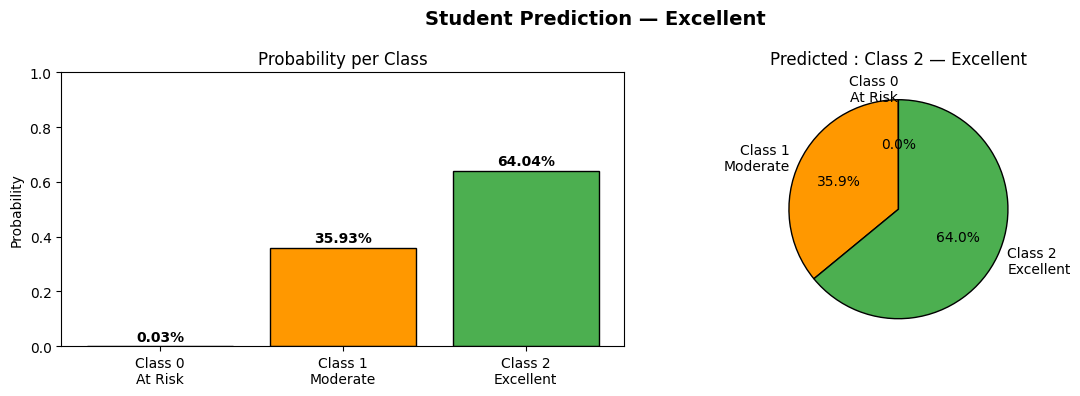

In [20]:
# ── Real median values from your actual dataset ──
# Tier 0 = At Risk | Tier 1 = Moderate | Tier 2 = Excellent

at_risk_student = {
    "Diet_Quality"            : 2.0,    "Employment"              : 1.0,
    "Stress_Level"            : 7.5,    "Total_Productive_Hrs"    : 2.0,
    "Distraction_Hrs"         : 6.5,    "Study_Distraction_Ratio" : 0.23,
    "Wellbeing_Score"         : 0.0,    "Active_Engagement_Score" : 8.7,
    "Study_Quality"           : 2.0,    "AI_Enhanced_Study"       : 3.0,
    "Resource_Quality"        : 4.0,    "Focus_Ratio"             : 0.35,
    "Stress_Wellbeing"        : 1.25,   "AI_Engagement"           : 21.0,
    "Lifestyle_Index"         : 0.38,   "Study_Consistency"       : 1.0,
    "Time_Efficiency"         : 0.24,   "Digital_Balance"         : 0.42,
    "Academic_Momentum"       : 10.5,   "Stress_Load"             : 46.9,
}

moderate_student = {
    "Diet_Quality"            : 2.0,    "Employment"              : 0.0,
    "Stress_Level"            : 5.5,    "Total_Productive_Hrs"    : 3.0,
    "Distraction_Hrs"         : 5.0,    "Study_Distraction_Ratio" : 0.49,
    "Wellbeing_Score"         : 2.0,    "Active_Engagement_Score" : 13.5,
    "Study_Quality"           : 4.0,    "AI_Enhanced_Study"       : 6.0,
    "Resource_Quality"        : 4.0,    "Focus_Ratio"             : 0.65,
    "Stress_Wellbeing"        : 0.75,   "AI_Engagement"           : 33.6,
    "Lifestyle_Index"         : 0.42,   "Study_Consistency"       : 2.0,
    "Time_Efficiency"         : 0.47,   "Digital_Balance"         : 0.65,
    "Academic_Momentum"       : 21.0,   "Stress_Load"             : 28.2,
}

excellent_student = {
    "Diet_Quality"            : 9.0,    "Employment"              : 0.0,
    "Stress_Level"            : 2.5,    "Total_Productive_Hrs"    : 8.5,
    "Distraction_Hrs"         : 1.0,    "Study_Distraction_Ratio" : 0.11,
    "Wellbeing_Score"         : 9.0,    "Active_Engagement_Score" : 10.5,
    "Study_Quality"           : 10.0,   "AI_Enhanced_Study"       : 10.0,
    "Resource_Quality"        : 9.5,    "Focus_Ratio"             : 8.5,
    "Stress_Wellbeing"        : 0.28,   "AI_Engagement"           : 12.5,
    "Lifestyle_Index"         : 0.90,   "Study_Consistency"       : 5.0,
    "Time_Efficiency"         : 1.35,   "Digital_Balance"         : 0.95,
    "Academic_Momentum"       : 55.0,   "Stress_Load"             : 0.20,
}

# ── Pick which student to test ──
my_student = excellent_student  # ← swap to at_risk_student or excellent_student

class_names  = {0: "At Risk", 1: "Moderate", 2: "Excellent"}
student_df   = pd.DataFrame([my_student])
student_scaled = s.transform(student_df)

best_model   = models['lr'] 
y_pred       = best_model.predict(student_scaled)[0]
y_prob       = best_model.predict_proba(student_scaled)[0]
class_labels = best_model.classes_

print("=== Student Prediction ===")
for label, prob in zip(class_labels, y_prob):
    bar = '█' * int(prob * 30)
    print(f"  {class_names[label]:10s} (Class {label}) : {prob:.2%}  {bar}")
print(f"\n  ➤ Predicted Tier : Class {y_pred} — {class_names[y_pred]}")

colors = ['#F44336', '#FF9800', '#4CAF50']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Student Prediction — {class_names[y_pred]}', fontsize=14, fontweight='bold')

labels = [f"Class {l}\n{class_names[l]}" for l in class_labels]
bars = axes[0].bar(labels, y_prob, color=colors, edgecolor='black')
axes[0].set_title('Probability per Class')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1)
for bar, prob in zip(bars, y_prob):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.2%}', ha='center', fontweight='bold')

axes[1].pie(y_prob, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title(f'Predicted : Class {y_pred} — {class_names[y_pred]}')

plt.tight_layout()
plt.show()